# History feature engineering

Two-stage experiment for **history features** used in [`3 fatigue_modeling.ipynb`](3%20fatigue_modeling.ipynb):

1. **Tune construction** — exhaustive grid over `ewma_alpha` (10 log-spaced values in [0.1, 0.5]) and **all 64 rolling-window combos** ({2, 3, 5, 7} per column) for the three rolling-mean history features (640 configs total, all 7 history columns).
2. **Ablation** — with best construction fixed, find which history columns to keep (leave-one-out ranking + forward selection).

Decisions use **GroupKFold CV on train/val only**. Held-out test is used once in §3.

**Proxy model:** `catboost_ordinal` with fixed hyperparameters (`HISTORY_PROXY_PARAMS` in config — Optuna best from `catboost_ordinal_history` in the main notebook §3 History). There is **no model Optuna** in this notebook; only history construction (§1) and feature subset (§2) vary.

Rolling-mean history columns use window-agnostic names (e.g. `activity_logsum_roll_mean`); tuned window lengths live in `ROLLING_WINDOWS` in config.


In [1]:
%pip install -q -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

_src = Path('../../src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

for _mod in [k for k in list(sys.modules) if k == 'modeling' or k.startswith('modeling.')]:
    del sys.modules[_mod]

import pandas as pd
from modeling.config import (
    DATA_PATH,
    EWMA_ALPHA,
    EWMA_ALPHA_GRID,
    HISTORY_ABLATION_MODEL,
    HISTORY_CANDIDATE_FEATURES,
    HISTORY_FEATURES,
    HISTORY_PROXY_PARAMS,
    N_CV_FOLDS,
    ROLLING_WINDOWS,
)
from modeling.data import load_fatigue_data, prepare_splits, split_summary_table
from modeling.history_tuning import (
    cv_mae_with_history,
    exhaustive_tune_history_construction,
    plot_history_construction_grid_mae,
    prepare_tuned_bundle,
    rolling_windows_from_construction_params,
    run_forward_selection,
    run_leave_one_out_ablation,
    summarize_history_recommendation,
    test_mae_with_history,
)


## Load data and split


In [3]:
df = load_fatigue_data('../../' + DATA_PATH)
bundle = prepare_splits(df)

print(f"Rows: {len(df):,}  Participants: {df['id'].nunique()}")
display(split_summary_table(bundle))
print('Proxy model:', HISTORY_ABLATION_MODEL)
print('Proxy params:', HISTORY_PROXY_PARAMS)
print('Default construction: ewma_alpha=', EWMA_ALPHA)
print('Default rolling windows:', ROLLING_WINDOWS)


Rows: 3,331  Participants: 42


,split,participants,rows,mean_fatigue
0,train_val,34,2659,2.462204
1,test,8,672,2.653274


Proxy model: catboost_ordinal
Proxy params: {'iterations': 366, 'depth': 4, 'learning_rate': 0.034143215054019314, 'l2_leaf_reg': 3.5798039531025863}
Default construction: ewma_alpha= 0.366976
Default rolling windows: {'activity_logsum_roll_mean': 2, 'calories_sum_roll_mean': 2, 'very_roll_mean': 5}


## 1. Tune history construction

Exhaustive grid search: **10 log-spaced** `ewma_alpha` values (`EWMA_ALPHA_GRID` in [0.1, 0.5]) × **64 rolling-window combos** (4³ choices for `activity_roll_window`, `calories_roll_window`, `very_roll_window` ∈ {2, 3, 5, 7}) = **640 configurations**. All 7 `HISTORY_CANDIDATE_FEATURES` are included. The proxy model is `catboost_ordinal` with fixed `HISTORY_PROXY_PARAMS` (no model Optuna here).

Expect **640 × 5 CV folds ≈ 3,200** proxy fits; runtime is typically **1–3+ hours**.


In [4]:
default_cv_mae = cv_mae_with_history(
    df,
    bundle.train_val_mask,
    bundle.test_mask,
    bundle.y_ord_train_val,
    bundle.groups_train_val,
    model_name=HISTORY_ABLATION_MODEL,
    ewma_alpha=EWMA_ALPHA,
    rolling_windows=ROLLING_WINDOWS,
    history_cols=list(HISTORY_CANDIDATE_FEATURES),
    n_splits=N_CV_FOLDS,
    test_ids=bundle.test_ids,
)
print(f'Default construction CV MAE (7 cols): {default_cv_mae:.4f}')
print(f'Grid size: {len(EWMA_ALPHA_GRID)} alphas x 64 rolling combos = {len(EWMA_ALPHA_GRID) * 64} configs')

construction_result = exhaustive_tune_history_construction(
    df,
    bundle,
    model_name=HISTORY_ABLATION_MODEL,
    n_splits=N_CV_FOLDS,
)
print(f"Evaluated {construction_result['n_evaluated']} configs")
print('Top 10 configs by CV MAE:')
display(construction_result['grid_results'].sort_values('cv_mae').head(10))

best_alpha = construction_result['best_params']['ewma_alpha']
best_rolling_windows = rolling_windows_from_construction_params(
    construction_result['best_params']
)
print(f'Best construction: ewma_alpha={best_alpha:.4f}')
print('Best rolling windows:')
for col, window in best_rolling_windows.items():
    print(f'  {col}: {window}')
print(f"Best CV MAE: {construction_result['best_cv_mae']:.4f}")
print(f"Delta vs default: {construction_result['best_cv_mae'] - default_cv_mae:+.4f}")


Default construction CV MAE (7 cols): 0.8387
Grid size: 10 alphas x 64 rolling combos = 640 configs
  [1/640] best cv_mae so far: 0.8584
  [50/640] best cv_mae so far: 0.8510
  [100/640] best cv_mae so far: 0.8453
  [150/640] best cv_mae so far: 0.8435
  [200/640] best cv_mae so far: 0.8435
  [250/640] best cv_mae so far: 0.8435
  [300/640] best cv_mae so far: 0.8383
  [350/640] best cv_mae so far: 0.8383
  [400/640] best cv_mae so far: 0.8380
  [450/640] best cv_mae so far: 0.8336
  [500/640] best cv_mae so far: 0.8336
  [550/640] best cv_mae so far: 0.8336
  [600/640] best cv_mae so far: 0.8336
  [640/640] best cv_mae so far: 0.8336
Evaluated 640 configs
Top 10 configs by CV MAE:


,eval_index,ewma_alpha,cv_mae,activity_roll_window,calories_roll_window,very_roll_window
449,450,0.349658,0.833584,2,2,3
395,396,0.292402,0.838037,2,5,7
268,269,0.204481,0.838330,2,7,2
443,444,0.292402,0.839061,7,5,7
387,388,0.292402,0.839078,2,2,7
333,334,0.244521,0.839463,2,7,3
394,395,0.292402,0.839571,2,5,5
412,413,0.292402,0.839730,3,7,2
280,281,0.204481,0.839752,3,5,2
396,397,0.292402,0.839838,2,7,2


Best construction: ewma_alpha=0.3497
Best rolling windows:
  activity_logsum_roll_mean: 2
  calories_sum_roll_mean: 2
  very_roll_mean: 3
Best CV MAE: 0.8336
Delta vs default: -0.0051


### CV MAE across grid evaluations

Line plot of CV MAE for each grid configuration in **evaluation order** (1..N). The highlighted point is the global minimum (best construction params).

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'History construction grid search'}, xlabel='Grid evaluation index', ylabel='CV MAE'>)

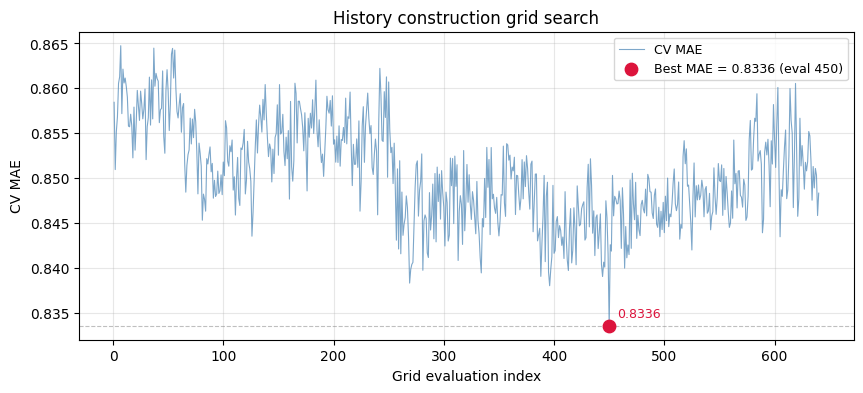

In [5]:
plot_history_construction_grid_mae(
    construction_result["grid_results"],
    best_cv_mae=construction_result["best_cv_mae"],
)

## 2. History feature ablation

Rebuild the bundle with tuned construction params, then:
- **Leave-one-out:** drop each history column; higher `cv_mae_increase_vs_all` = more important.
- **Forward selection:** start from base features only; greedily add columns while CV MAE improves.

Same proxy model and fixed `HISTORY_PROXY_PARAMS` as §1.


In [6]:
tuned_bundle = prepare_tuned_bundle(df, best_alpha, rolling_windows=best_rolling_windows)

all_features_cv_mae, feature_importance = run_leave_one_out_ablation(
    df,
    tuned_bundle,
    ewma_alpha=best_alpha,
    rolling_windows=best_rolling_windows,
    model_name=HISTORY_ABLATION_MODEL,
    n_splits=N_CV_FOLDS,
)
print(f'All-{len(HISTORY_FEATURES)}-feature CV MAE: {all_features_cv_mae:.4f}')
print('Removing each history feature — higher cv_mae_increase_vs_all = more important:')
display(feature_importance)


All-3-feature CV MAE: 0.8336
Removing each history feature — higher cv_mae_increase_vs_all = more important:


,history_feature,n_history_features_remaining,cv_mae_without_feature,cv_mae_increase_vs_all
0,fatigue_ewma,6,0.875473,0.041889
1,fatigue_expanding_mean,6,0.871096,0.037512
2,fatigue_lag1,6,0.854896,0.021311
3,calories_sum_roll_mean,6,0.854065,0.020481
4,fatigue_delta_lag1,6,0.850910,0.017326
5,very_roll_mean,6,0.850518,0.016934
6,activity_logsum_roll_mean,6,0.846675,0.013090


In [7]:
forward_selected, forward_cv_mae, forward_path = run_forward_selection(
    df,
    tuned_bundle,
    ewma_alpha=best_alpha,
    rolling_windows=best_rolling_windows,
    model_name=HISTORY_ABLATION_MODEL,
    n_splits=N_CV_FOLDS,
)
print('Forward selection path:')
display(forward_path)
print(f'Recommended subset ({len(forward_selected)} features): {forward_selected}')
print(f'Forward-selection CV MAE: {forward_cv_mae:.4f}')

recommendation = summarize_history_recommendation(
    construction_result,
    forward_selected,
    forward_cv_mae,
    default_cv_mae=default_cv_mae,
    feature_importance=feature_importance,
)
pd.Series(recommendation)


Forward selection path:


,step,added_feature,selected_features,cv_mae,delta_vs_prev
0,0,(base only),[],1.232630,0.000000
1,1,fatigue_ewma,[fatigue_ewma],0.881293,-0.351337
2,2,fatigue_expanding_mean,"[fatigue_ewma, fatigue_expanding_mean]",0.845554,-0.035740
3,3,fatigue_lag1,"[fatigue_ewma, fatigue_expanding_mean, fatigue...",0.829649,-0.015905


Recommended subset (3 features): ['fatigue_ewma', 'fatigue_expanding_mean', 'fatigue_lag1']
Forward-selection CV MAE: 0.8296


ewma_alpha                                                                     0.349658
rolling_windows                       {'activity_logsum_roll_mean': 2, 'calories_sum...
history_features                      [fatigue_ewma, fatigue_expanding_mean, fatigue...
construction_cv_mae                                                            0.833584
forward_selection_cv_mae                                                       0.829649
default_ewma_alpha                                                             0.366976
default_rolling_windows               {'activity_logsum_roll_mean': 2, 'calories_sum...
default_history_features              [fatigue_ewma, fatigue_expanding_mean, fatigue...
activity_roll_window                                                                  2
calories_roll_window                                                                  2
very_roll_window                                                                      3
default_construction_cv_mae     

## 3. One-shot test evaluation

Single held-out test MAE with the recommended construction params and forward-selected history subset. Same `catboost_ordinal` proxy and `HISTORY_PROXY_PARAMS`. Use for reporting only — not for tuning decisions.


In [8]:
test_mae = test_mae_with_history(
    df,
    tuned_bundle.train_val_mask,
    tuned_bundle.test_mask,
    tuned_bundle.y_ord_train_val,
    tuned_bundle.y_ord_test,
    model_name=HISTORY_ABLATION_MODEL,
    ewma_alpha=best_alpha,
    rolling_windows=best_rolling_windows,
    history_cols=forward_selected,
)
print(f'Proxy test MAE (recommended config): {test_mae:.4f}')


Proxy test MAE (recommended config): 0.8899


## 4. Apply to main pipeline

When satisfied with the results above, copy into [`src/modeling/config.py`](../../src/modeling/config.py):

```python
EWMA_ALPHA = ...        # from recommendation['ewma_alpha']
ROLLING_WINDOWS = {       # from recommendation['rolling_windows']
    'activity_logsum_roll_mean': ...,
    'calories_sum_roll_mean': ...,
    'very_roll_mean': ...,
}
HISTORY_FEATURES = [    # from recommendation['history_features']
    ...,
]
```

Then re-run §3 History in [`3 fatigue_modeling.ipynb`](3%20fatigue_modeling.ipynb) (full model Optuna tuning, not just the proxy).


In [9]:
print('Suggested config.py updates:')
print(f'EWMA_ALPHA = {recommendation["ewma_alpha"]:.6f}')
print('ROLLING_WINDOWS = {')
for col, window in recommendation['rolling_windows'].items():
    print(f'    "{col}": {window},')
print('}')
print('HISTORY_FEATURES = [')
for feature in recommendation['history_features']:
    print(f'    "{feature}",')
print(']')


Suggested config.py updates:
EWMA_ALPHA = 0.349658
ROLLING_WINDOWS = {
    "activity_logsum_roll_mean": 2,
    "calories_sum_roll_mean": 2,
    "very_roll_mean": 3,
}
HISTORY_FEATURES = [
    "fatigue_ewma",
    "fatigue_expanding_mean",
    "fatigue_lag1",
]
